In [1]:
import pandas as pd

In [2]:
medical_df = pd.read_csv("insurance.csv")

In [3]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [5]:
fig = px.histogram(medical_df, x="age", nbins=47, title="Distribution of Age")
fig.update_layout(bargap=0.1)   
fig.show()

In [10]:
fig = px.histogram(medical_df, x="bmi",color_discrete_sequence=['red'], marginal="box", title="Distribution of BMI")
fig.update_layout(bargap=0.1)
fig.show()

In [11]:
fig = px.histogram(medical_df, x="charges",color_discrete_sequence=['red'], marginal="box", title="Distribution of BMI")
fig.update_layout(bargap=0.1)
fig.show()

In [13]:
fig = px.histogram(medical_df, x="charges", marginal="box",
                   color="smoker",
                   color_discrete_sequence=['red', 'blue'],
                    title="Distribution of Charges")
fig.update_layout(bargap=0.1)
fig.show()

In [14]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [15]:
px.histogram(medical_df, x="smoker", color="sex")

In [22]:
fig = px.scatter(medical_df, x="age", y="charges",color="smoker")
fig.update_traces(marker_size=5)
fig.show()

In [24]:
fig = px.scatter(medical_df, x="bmi", y="charges",color="smoker")
fig.update_traces(marker_size=5)
fig.show()

In [27]:
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984772)

In [28]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


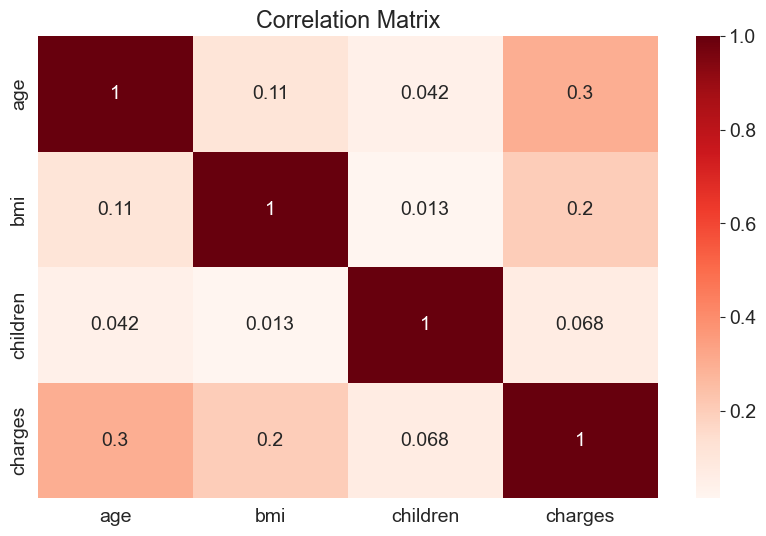

In [41]:
sns.heatmap(medical_df.corr(numeric_only=True),cmap='Reds', annot=True)
plt.title('Correlation Matrix')
plt.show()


In [43]:
non_smokers_df = medical_df[medical_df.smoker == 'no']
non_smokers_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


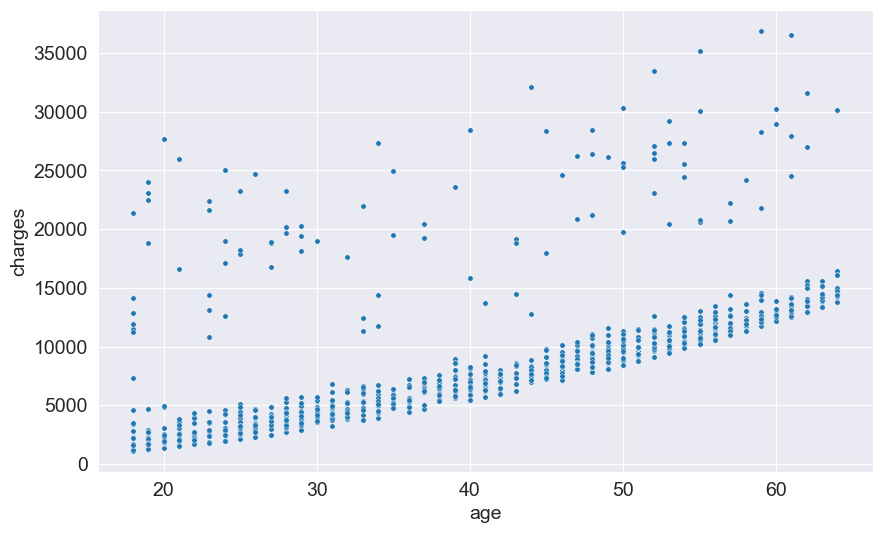

In [50]:
sns.scatterplot(data=non_smokers_df, x="age", y="charges",s=15)
plt.show()

In [55]:
inputs = non_smokers_df[["age"]]
target = non_smokers_df.charges


In [58]:
from sklearn.linear_model import LinearRegression


In [59]:
model = LinearRegression()

In [60]:
model.fit(inputs, target)

LinearRegression()

In [61]:
import numpy as np

In [63]:
model.predict(np.array([[23], 
                        [37], 
                        [61]]))

c:\Users\mmkb3\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [67]:
model.coef_


array([267.24891283])

In [68]:
model.intercept_


np.float64(-2091.4205565650827)

In [70]:
print("Min charges:", medical_df["charges"].min())
print("Max charges:", medical_df["charges"].max())
print("Mean charges:", medical_df["charges"].mean())

Min charges: 1121.8739
Max charges: 63770.42801
Mean charges: 13270.422265141257


In [71]:
medical_df.groupby("smoker")["charges"].mean()


smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64